In [2]:
%pip install statsmodels
%pip install pandas
%pip install numpy 
%pip install python-math
%pip install networkx

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd 
import numpy as np
import statsmodels.api as sm
import math


In [31]:
# Load data
data = pd.read_csv("/Users/juliastephenson/Downloads/DGS1 quarterly observations 20 years.csv")

# Convert to datetime
data['observation_date1'] = pd.to_datetime(data['observation_date'])

# Drop unnecessary columns FIRST
data = data.drop(columns=['observation_date'])  # drop the string date column

# Set datetime as index
data = data.set_index('observation_date1')

# Now resample
data_yearly = data.resample('Y').first()  # Use 'Y' instead of 'A' (future-proof)

# Reset index if you want
data = data_yearly.reset_index()

data


/var/folders/5x/l3mv71f10r7ds38v55mcts_00000gn/T/ipykernel_52558/1364517012.py:14: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  data_yearly = data.resample('Y').first()  # Use 'Y' instead of 'A' (future-proof)


,observation_date1,DGS1,Unnamed: 2,1 year US Treasury yield
0,2004-12-31,2.75,NaN,NaN
1,2005-12-31,3.35,NaN,NaN
2,2006-12-31,4.82,NaN,NaN
3,2007-12-31,4.90,NaN,NaN
4,2008-12-31,1.55,NaN,NaN
5,2009-12-31,0.57,NaN,NaN
6,2010-12-31,0.41,NaN,NaN
7,2011-12-31,0.30,NaN,NaN
8,2012-12-31,0.19,NaN,NaN
9,2013-12-31,0.14,NaN,NaN


In [32]:
# Bond characteristics
face_value = 100     # Face value
coupon_rate = 0.035  # 3.5% annual coupon
maturity = 6         # 6 years
frequency = 1        # Annual payments (so 6 total periods)
coupon = face_value * coupon_rate / frequency

In [33]:
# Noncallable coupon bond 
# Fair price using STRIPS curve 
# Strips rates 
rate_0_1 = 3.880 / 100
rate_0_2 = 3.985 / 100
rate_0_3 = 4.085 / 100
rate_0_4 = 4.163 / 100
rate_0_5 = 4.284 / 100
rate_0_6 = 4.385 / 100

# Discounted cash flows 
coupon_1 = coupon * np.exp(-rate_0_1 * 1)
coupon_2 = coupon * np.exp(-rate_0_2 * 2)
coupon_3 = coupon * np.exp(-rate_0_3 * 3)
coupon_4 = coupon * np.exp(-rate_0_4 * 4)
coupon_5 = coupon * np.exp(-rate_0_5 * 5)
coupon_6 = coupon * np.exp(-rate_0_6 * 6) + face_value * np.exp(-rate_0_6 * 6)

# Total price
price_strips = coupon_1 + coupon_2 + coupon_3 + coupon_4 + coupon_5 + coupon_6
print('price using STRIPS curve: $', price_strips)

# Delta 
# Delta is the change in price of the bond for a 1% change in yield
delta_noncallable = (coupon_1 * 1 + coupon_2 * 2 + coupon_3 * 3 + coupon_4 * 4 + coupon_5 * 5 + coupon_6 * 6) / 100
print('Delta noncallable: $', delta_noncallable)



price using STRIPS curve: $ 95.04009839976594
Delta noncallable: $ 5.224387370090503


In [34]:
from statsmodels.tsa.ar_model import AutoReg

# Fit an AR(1) model
ar_model = AutoReg(data['DGS1'], lags=1).fit()

# Print the summary of the model
print(ar_model.summary())

# Long term mean, mean reversion speed, and volatility
# the long term mean is the intercept divided by (1 - AR coefficient)
# the mean reversion speed is the AR coefficient
# the volatility is the square root of the estimated variance
# Note: The model assumes that the time series is stationary (the mean and variance do not change over time- they are iid)
long_term_mean = ar_model.params[0] / (1 - ar_model.params[1])
mean_reversion_speed = ar_model.params[1]
volatility = np.sqrt(ar_model.sigma2)
print(f"Long-term mean: {long_term_mean}")
print(f"Mean reversion speed: {mean_reversion_speed}")
print(f"Volatility: {volatility}")


                            AutoReg Model Results                             
Dep. Variable:                   DGS1   No. Observations:                   21
Model:                     AutoReg(1)   Log Likelihood                 -32.539
Method:               Conditional MLE   S.D. of innovations              1.231
Date:                Sat, 26 Apr 2025   AIC                             71.078
Time:                        21:24:47   BIC                             74.065
Sample:                             1   HQIC                            71.661
                                   21                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4486      0.385      1.166      0.244      -0.305       1.203
DGS1.L1        0.7908      0.168      4.709      0.000       0.462       1.120
                                    Roots           

/var/folders/5x/l3mv71f10r7ds38v55mcts_00000gn/T/ipykernel_52558/1140650095.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  long_term_mean = ar_model.params[0] / (1 - ar_model.params[1])
/var/folders/5x/l3mv71f10r7ds38v55mcts_00000gn/T/ipykernel_52558/1140650095.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_reversion_speed = ar_model.params[1]


In [35]:
# Vasicek parameters (example)
phi = mean_reversion_speed        # Mean reversion speed (from AR(1))
mu = long_term_mean               # Long-term mean rate
sigma = volatility                # Volatility
dt = 1   # Time step (semiannual)


# Calculate the first step of the Vasicek model
step_1 = volatility * np.sqrt(-2 * np.log(mean_reversion_speed)) * np.sqrt(1)
step_1 = round(step_1, 3)
step_1 = .115

# Starting rate from STRIPS curve
rate_0_1 = 3.88

In [36]:
def build_rate_tree(r0, step, n_periods):
    # Initialize the tree with the starting rate
    tree = [[r0]]
    
    # Build the tree
    for t in range(1, n_periods + 1):
        prev = tree[-1]
        row = [(r + step) for r in prev] + [(prev[-1] - step)]
        tree.append(row)
    
    # Each element in the tree is rounded to 4 decimal places
    tree = [[round(r, 4) for r in row] for row in tree]
    return tree


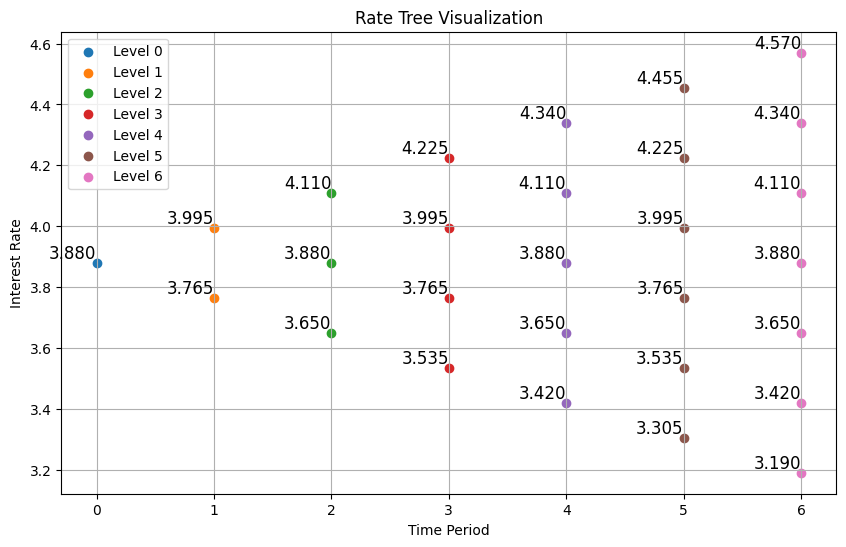

Rate tree: 


[[3.88],
 [3.995, 3.765],
 [4.11, 3.88, 3.65],
 [4.225, 3.995, 3.765, 3.535],
 [4.34, 4.11, 3.88, 3.65, 3.42],
 [4.455, 4.225, 3.995, 3.765, 3.535, 3.305],
 [4.57, 4.34, 4.11, 3.88, 3.65, 3.42, 3.19]]

In [37]:
# Testing- showing that the tree is built correctly
import matplotlib.pyplot as plt

# Build the rate tree
rate_tree = build_rate_tree(rate_0_1, step_1, maturity)

# Visualize the tree with labels
plt.figure(figsize=(10, 6))
for i, level in enumerate(rate_tree):
    x = [i] * len(level) # x-coordinates for each level
    y = level  # y-coordinates are the rates
    plt.scatter(x, y, label=f"Level {i}")
    for j, rate in enumerate(level):
        plt.text(x[j], y[j], f"{rate:.3f}", fontsize=12, ha='right', va='bottom')  # Add labels to each point

plt.title("Rate Tree Visualization")
plt.xlabel("Time Period")
plt.ylabel("Interest Rate")
plt.legend()
plt.grid()
plt.show()
print("Rate tree: ")
rate_tree


In [38]:
def compute_dynamic_p(r, phi, mu, dt, sigma):
    p = (1 / 2) + ((mu - r) * np.sqrt(-np.log(phi)) / (sigma * np.sqrt(8)))
    return p



In [39]:
# Finding the price tree
def price_coupon_bond_vasicek(rate_tree, coupon, face_value, dt, phi, mu, step, sigma): 
    n = len(rate_tree) - 1
    price_tree = [[0] * len(level) for level in rate_tree]  # Initialize price tree with zeros

    # Step 1: Final cash flows = face + coupon at maturity
    price_tree[-1] = [face_value + coupon for _ in rate_tree[-1]]

    # Step 2: Work backward
    for t in range(n - 1, -1, -1):
        for i in range(t + 1):
            # Find the rate at this node 
            r = rate_tree[t][i]
            # Compute the dynamic probability to move up 
            p = compute_dynamic_p(r, phi, mu, dt, sigma)
            # Calculate the expected price at the next time step
            # The expected price is the weighted average of the two possible future prices 
            expected = ((p) * price_tree[t + 1][i]) + ((1-p) * price_tree[t + 1][i + 1])
            # Calculate the present value of the expected price
            discounted = np.exp(-r * .01 * dt) * expected
            # Add only the discounted coupon payment to the price at this node
            price_tree[t][i] = float(round(coupon + discounted, 3))
    return price_tree

In [40]:
vasicek_price_tree = price_coupon_bond_vasicek(rate_tree, coupon, face_value, dt, phi, mu, step_1, sigma)
print ('noncallable bond price using Vasicek model: $', vasicek_price_tree[0][0])

# Calculating the delta of the bond using the Vasicek model
delta_noncallable = - (vasicek_price_tree[1][0] - vasicek_price_tree[1][1]) / (rate_tree[1][0] - rate_tree[1][1])
print('Delta noncallable bond using Vasicek model: $', delta_noncallable)

# Delta using the shift method 
def rate_shift(rate_tree, shift):
    shifted_tree = []
    for level in rate_tree:
        shifted_level = [r + shift for r in level]
        shifted_tree.append(shifted_level)
    return shifted_tree
shifted_tree = rate_shift(rate_tree, 0.001)
price_shifted = price_coupon_bond_vasicek(shifted_tree, coupon, face_value, dt, phi, mu, step_1, sigma)[0][0]

# since the delta is the change in price for a 1% change in yield, we need to divide by 0.001
delta_noncallable_shift = -(price_shifted - vasicek_price_tree[0][0]) / 0.001
print('Delta noncallable bond using shift method: $', delta_noncallable_shift)

noncallable bond price using Vasicek model: $ 101.797
Delta noncallable bond using Vasicek model: $ 4.32608695652176
Delta noncallable bond using shift method: $ 6.000000000000227


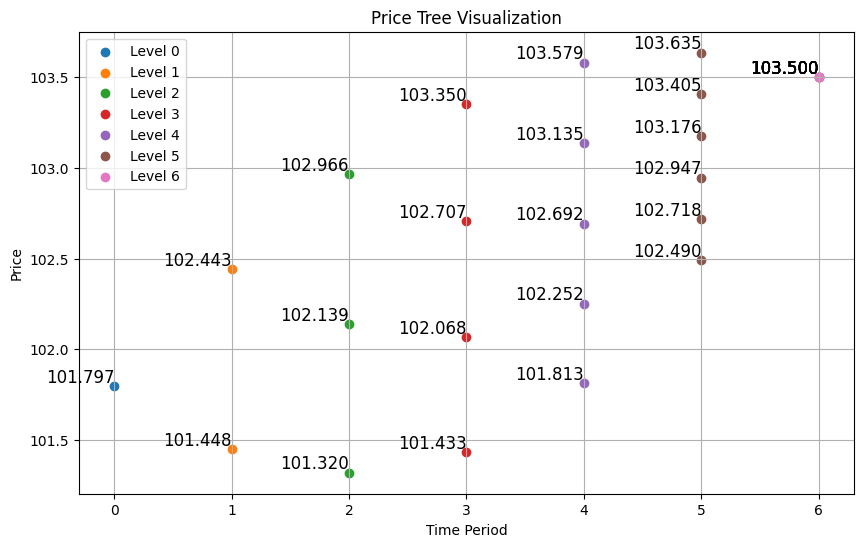

In [41]:
# visualize the price tree
plt.figure(figsize=(10, 6))
for i, level in enumerate(vasicek_price_tree):
    x = [i] * len(level) # x-coordinates for each level
    y = level  # y-coordinates are the rates
    plt.scatter(x, y, label=f"Level {i}")
    for j, rate in enumerate(level):
        plt.text(x[j], y[j], f"{rate:.3f}", fontsize=12, ha='right', va='bottom')  # Add labels to each point
plt.title("Price Tree Visualization")
plt.xlabel("Time Period")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [42]:
def build_probability_tree(rate_tree, phi, mu, dt, sigma):
    n = len(rate_tree)
    prob_tree = [[0.0] * len(row) for row in rate_tree]
    prob_tree[0][0] = 1.0  # Start at root with prob 1

    for t in range(n - 1):  # Loop over time
        for i in range(len(rate_tree[t])):  # Loop over nodes at time t
            r = rate_tree[t][i]
            p = compute_dynamic_p(r, phi, mu, dt, sigma)
            
            # Add probability to up move
            prob_tree[t + 1][i]     += prob_tree[t][i] * p
            # Add probability to down move
            prob_tree[t + 1][i + 1] += prob_tree[t][i] * (1 - p)

    # Convert all probabilities to standard float
    prob_tree = [[round(float(prob), 3) for prob in row] for row in prob_tree]
    return prob_tree
probability_tree = build_probability_tree(rate_tree, phi, mu, dt, sigma)
probability_tree

[[1.0],
 [0.259, 0.741],
 [0.063, 0.399, 0.538],
 [0.014, 0.152, 0.452, 0.382],
 [0.003, 0.048, 0.239, 0.445, 0.265],
 [0.001, 0.013, 0.099, 0.307, 0.401, 0.179],
 [0.0, 0.003, 0.035, 0.159, 0.345, 0.339, 0.119]]

In [43]:
# European call option 
exercise_price = 103

# Assume expiration is year 5
t_expire = 5

def european_call_option_value(price_tree, exercise_price, prob_tree, t_expire):
    total = 0.0
    for i in range(len(price_tree[t_expire])):
        payoff = max(0, price_tree[t_expire][i] - exercise_price)
        weighted_payoff = prob_tree[t_expire][i] * payoff
        total += weighted_payoff
    return float(total)

# Build probability tree from your rate tree
prob_tree = build_probability_tree(rate_tree, phi, mu, dt, sigma)

# Price the option
call_option_price = european_call_option_value(vasicek_price_tree, exercise_price, prob_tree, t_expire)
print("European call option price:", call_option_price)

# Calculate the callable bond price
# Value of Callable bond = value of noncallable bond - value of call option
callable_bond_price = vasicek_price_tree[0][0] - call_option_price
print("European Callable bond price: ", callable_bond_price)


def price_european_call_option_tree(price_tree, exercise_price, prob_tree, dt, rate_tree):
    # Initialize the option tree (same shape as price_tree)
    option_tree = [[0] * len(level) for level in price_tree]
    
    T = len(price_tree) - 1  # Final time index

    # 1. Set terminal payoffs (at maturity)
    for i in range(len(price_tree[T])):
        option_tree[T][i] = max(price_tree[T][i] - exercise_price, 0)

    # 2. Backward induction for option value
    for t in range(T - 1, -1, -1):
        for i in range(len(price_tree[t])):
            # Discount factor from node t, i
            discount_factor = np.exp(-rate_tree[t][i] * 0.01 * dt)
            # Expected continuation value
            expected_continuation = (
                prob_tree[t + 1][i] * option_tree[t + 1][i] +
                prob_tree[t + 1][i + 1] * option_tree[t + 1][i + 1]
            )

            # Since European, no early exercise: only continuation value discounted
            option_tree[t][i] = expected_continuation * discount_factor

    return option_tree
european_option_tree = price_european_call_option_tree(
    vasicek_price_tree,
    exercise_price,
    prob_tree,
    dt,
    rate_tree
)
# Delta of European callable bond
# Delta of callable = delta of noncallable - delta of call option
delta_euro_option = - (european_option_tree[1][0] - european_option_tree[1][1]) / (rate_tree[1][0] - rate_tree[1][1])
delta_european = delta_noncallable_shift - delta_euro_option
print("Delta of European: ", delta_european)


European call option price: 0.33010200000000195
European Callable bond price:  101.466898
Delta of European:  5.792049231324043


In [44]:
def am_call_option(price_tree, exercise_price, prob_tree, rate_tree):
    # Initialize the option value tree with zeros
    option_tree = [[0] * len(level) for level in price_tree]

    # Start by filling in the payoffs at maturity
    T = len(price_tree) - 1
    for i in range(len(price_tree[T])):
        option_tree[T][i] = max(price_tree[T][i] - exercise_price, 0)

    # Now work backward through the tree
    for t in range(T - 1, -1, -1):  # from T-1 down to 0
        for i in range(len(price_tree[t])):
            # Expected continuation value (expected value of future nodes)
            expected_continuation = (
                prob_tree[t + 1][i] * option_tree[t + 1][i] +
                prob_tree[t + 1][i + 1] * option_tree[t + 1][i + 1]
            ) * np.exp(-rate_tree[t][i] * 0.01 * dt)

            # Immediate exercise value
            immediate_exercise = max(price_tree[t][i] - exercise_price, 0)

            # American option value: maximum of immediate exercise and continuation
            option_tree[t][i] = max(immediate_exercise, expected_continuation)

    return option_tree

# Calculate the American call option price
# Calculate the American call option price and capture the option tree
option_tree = am_call_option(vasicek_price_tree, exercise_price, prob_tree, rate_tree)
american_call_option_price = option_tree[0][0]
print("American call option price:", american_call_option_price)

# Calculate the American callable bond price
american_callable_bond_price = vasicek_price_tree[0][0] - american_call_option_price
print("American Callable bond price:", american_callable_bond_price)

# Delta of American callable bond
# Delta of American callable bond = delta of noncallable - delta of call option
delta_am_option = - (option_tree[1][0] - option_tree[1][1]) / (rate_tree[1][0] - rate_tree[1][1])
delta_american = delta_noncallable_shift - delta_am_option
print("Delta of American: ", delta_american)


American call option price: 0.086111331504542
American Callable bond price: 101.71088866849546
Delta of American:  5.595829914451403
